In [4]:
# Restart kernel and reload modules to pick up config changes
%load_ext autoreload
%autoreload 2

# ODIR-5K Dataset Exploration

This notebook provides a comprehensive exploration of the Ocular Disease Intelligent Recognition (ODIR) dataset.

## Dataset Information

- **Patients**: 5,000
- **Images**: ~10,000 (left and right eye fundus photographs)
- **Disease Categories**: 8 (N, D, G, C, A, H, M, O)
- **Multi-label**: Yes - patients can have multiple diseases

## 1. Setup and Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Import custom utilities
from utils import (
    load_dataset, 
    get_disease_statistics,
    plot_disease_distribution,
    analyze_multilabel,
    plot_age_gender_distribution,
    visualize_samples,
    create_correlation_matrix
)
from config import DISEASE_LABELS, LABEL_COLUMNS, DISEASE_COLORS

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")

✓ Imports successful


## 2. Load Dataset

In [7]:
# Load the dataset (Excel file)
from pathlib import Path
data_file = Path("ODIR-5K/data.xlsx")
df = pd.read_excel(data_file)

print(f"\nDataset shape: {df.shape}")
print(f"Number of patients: {len(df)}")
print(f"\nColumn names:")
print(df.columns.tolist())


Dataset shape: (3500, 15)
Number of patients: 3500

Column names:
['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


## 3. Basic Data Inspection

In [ ]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [ ]:
# Data types and missing values
print("Data types and missing values:")
print(df.info())

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 

In [ ]:
# Statistical summary
print("Statistical summary:")
df.describe()

Statistical summary:


,ID,Patient Age,N,D,G,C,A,H,M,O
count,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000
mean,2271.150814,57.857947,0.328692,0.332134,0.062109,0.062891,0.049906,0.031758,0.047872,0.248436
std,1417.559018,11.727737,0.469775,0.471016,0.241372,0.242786,0.217768,0.175370,0.213513,0.432139
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,920.750000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2419.500000,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3294.000000,66.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4784.000000,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Disease Distribution Analysis

In [ ]:
# Get disease statistics
disease_stats = get_disease_statistics(df)
print("Disease Statistics:")
print(disease_stats.to_string(index=False))

Disease Statistics:
Disease Code                     Disease Name  Count Percentage
           N                           Normal   2101     32.87%
           D                         Diabetes   2123     33.21%
           G                         Glaucoma    397      6.21%
           C                         Cataract    402      6.29%
           A Age-related Macular Degeneration    319      4.99%
           H                     Hypertension    203      3.18%
           M              Pathological Myopia    306      4.79%
           O     Other diseases/abnormalities   1588     24.84%


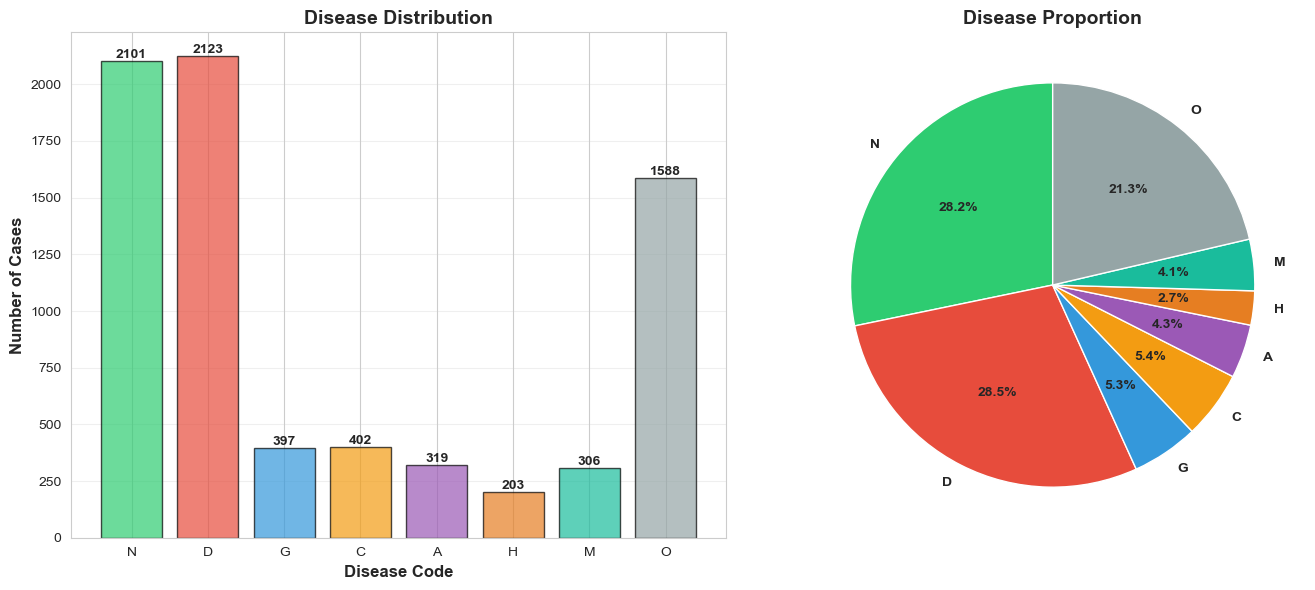

In [ ]:
# Visualize disease distribution
stats = plot_disease_distribution(df, figsize=(14, 6))

## 5. Multi-Label Analysis

In [ ]:
# Analyze multi-label distribution
multilabel_analysis = analyze_multilabel(df)

Multi-label Analysis:
  Single disease: 5391 patients
  Multiple diseases: 1001 patients
  No disease labeled: 0 patients
  Max diseases per patient: 3
  Avg diseases per patient: 1.16


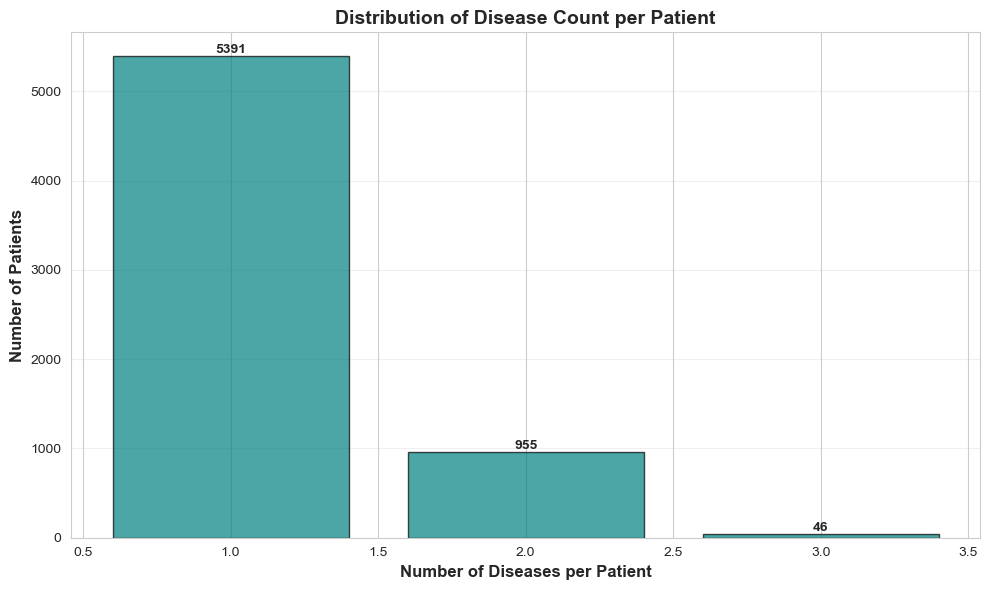

In [ ]:
# Visualize number of diseases per patient
disease_counts = df[LABEL_COLUMNS].sum(axis=1)

plt.figure(figsize=(10, 6))
count_dist = disease_counts.value_counts().sort_index()
plt.bar(count_dist.index, count_dist.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Number of Diseases per Patient', fontsize=12, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12, fontweight='bold')
plt.title('Distribution of Disease Count per Patient', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (count, freq) in enumerate(zip(count_dist.index, count_dist.values)):
    plt.text(count, freq, str(freq), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Disease Co-occurrence Analysis

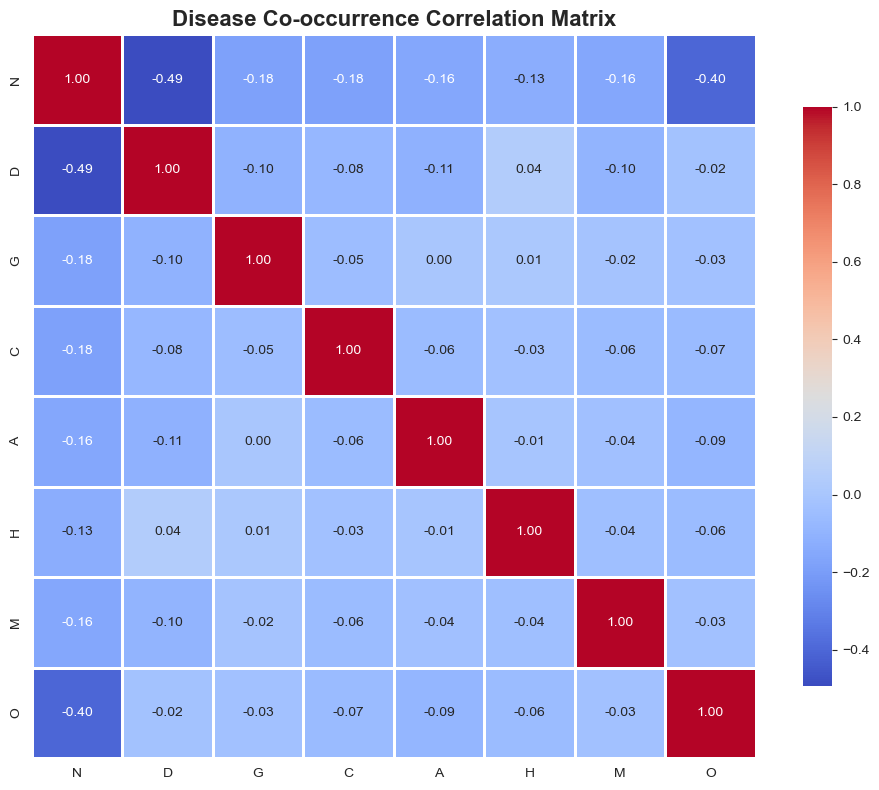

In [ ]:
# Create correlation matrix for disease co-occurrence
corr_matrix = create_correlation_matrix(df, figsize=(10, 8))

In [ ]:
# Find most common disease combinations
print("Most common disease combinations:")

# Create combination labels
df_labels = df[LABEL_COLUMNS].copy()
df_labels['combination'] = df_labels.apply(
    lambda row: '+'.join([label for label in LABEL_COLUMNS if row[label] == 1]), 
    axis=1
)

combination_counts = df_labels['combination'].value_counts().head(10)
print(combination_counts)

Most common disease combinations:
combination
N      2101
D      1376
O       894
D+O     464
C       276
A       234
G       232
M       206
D+H      88
H        72
Name: count, dtype: int64


## 7. Patient Demographics

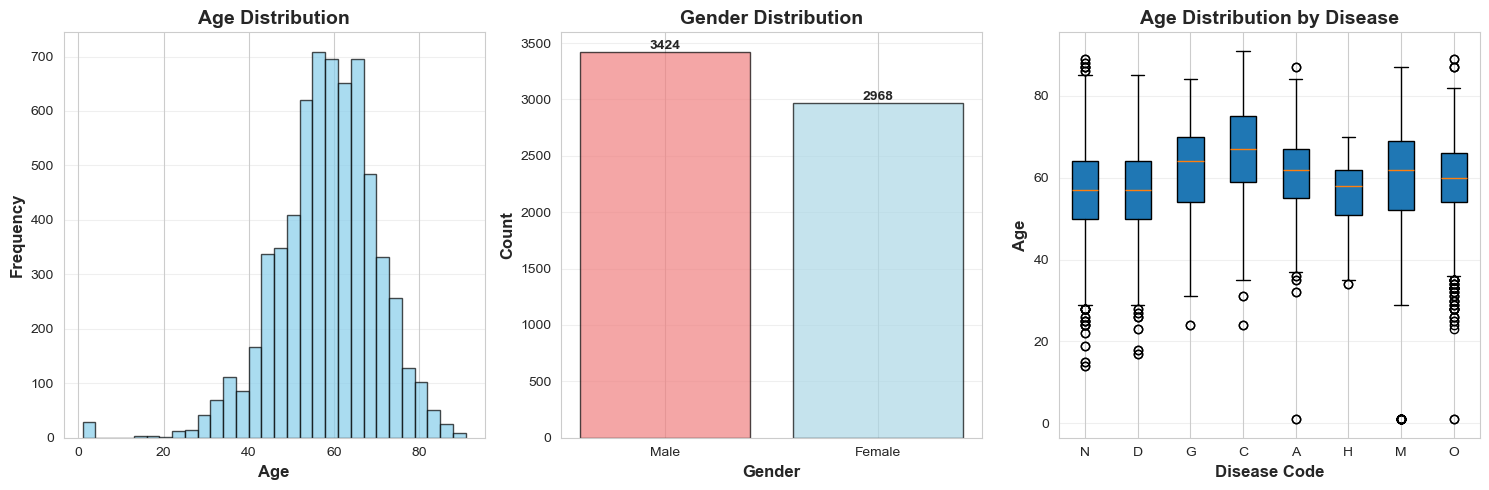

In [ ]:
# Plot age and gender distribution
plot_age_gender_distribution(df, figsize=(15, 5))

In [ ]:
# Age statistics by disease
print("Age statistics by disease:\n")
for label in LABEL_COLUMNS:
    if label in df.columns and 'Patient Age' in df.columns:
        ages = df[df[label] == 1]['Patient Age'].dropna()
        if len(ages) > 0:
            print(f"{label} ({DISEASE_LABELS[label]}):")
            print(f"  Mean age: {ages.mean():.1f}")
            print(f"  Median age: {ages.median():.1f}")
            print(f"  Age range: {ages.min():.0f} - {ages.max():.0f}")
            print()

Age statistics by disease:

N (Normal):
  Mean age: 56.7
  Median age: 57.0
  Age range: 14 - 89

D (Diabetes):
  Mean age: 56.3
  Median age: 57.0
  Age range: 17 - 85

G (Glaucoma):
  Mean age: 62.4
  Median age: 64.0
  Age range: 24 - 84

C (Cataract):
  Mean age: 66.5
  Median age: 67.0
  Age range: 24 - 91

A (Age-related Macular Degeneration):
  Mean age: 60.8
  Median age: 62.0
  Age range: 1 - 87

H (Hypertension):
  Mean age: 56.1
  Median age: 58.0
  Age range: 34 - 70

M (Pathological Myopia):
  Mean age: 56.5
  Median age: 62.0
  Age range: 1 - 87

O (Other diseases/abnormalities):
  Mean age: 59.3
  Median age: 60.0
  Age range: 1 - 89



## 8. Sample Image Visualization

Visualizing random samples...


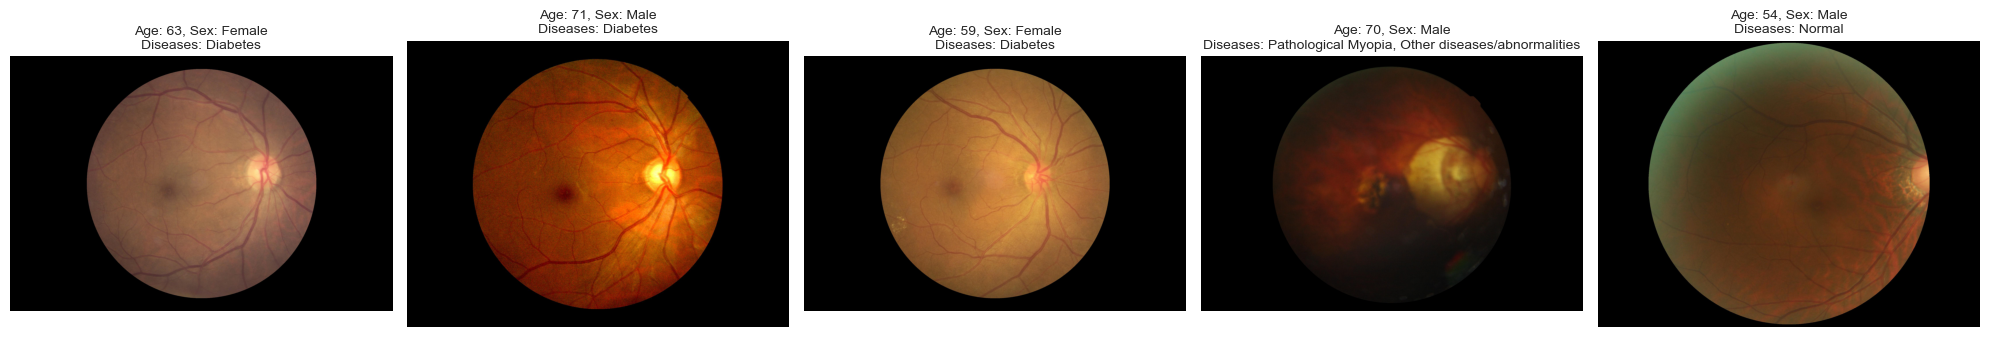

In [ ]:
# Visualize random samples
print("Visualizing random samples...")
visualize_samples(df, n_samples=5, image_column='Right-Fundus', show_labels=True)

Visualizing samples by disease category...


Normal (N):


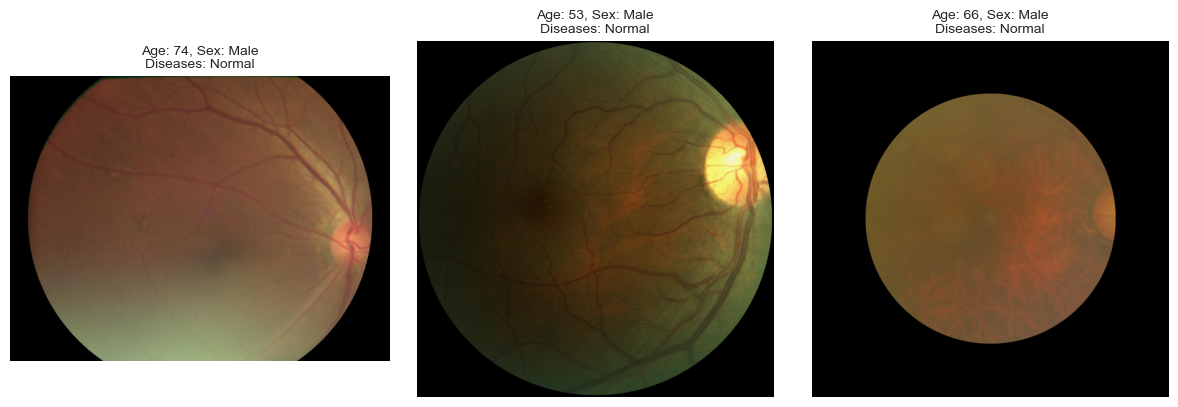


Diabetes (D):


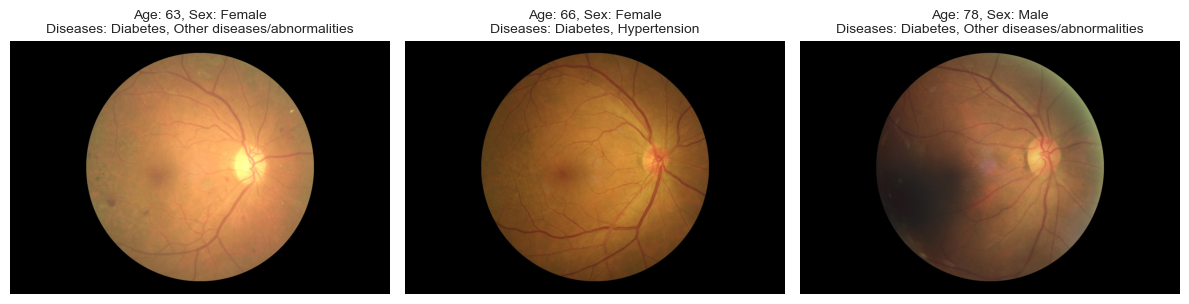


Glaucoma (G):


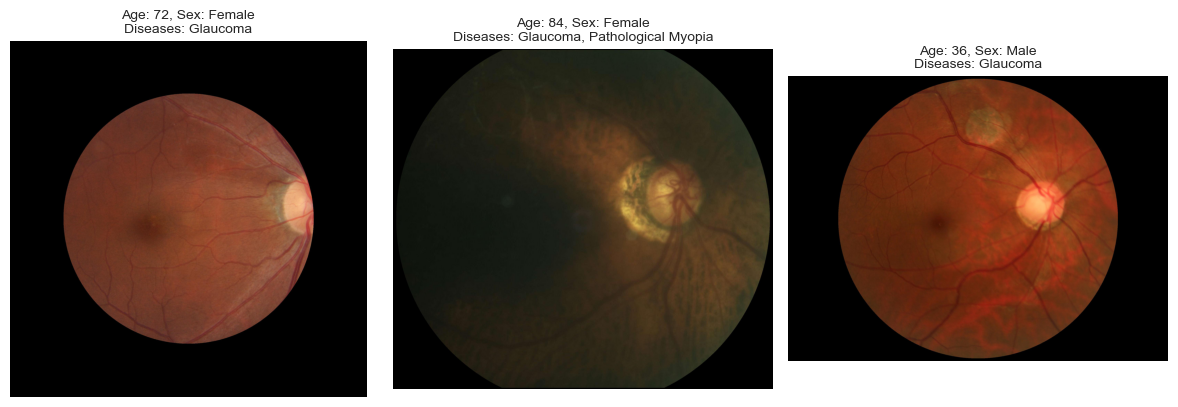


Cataract (C):


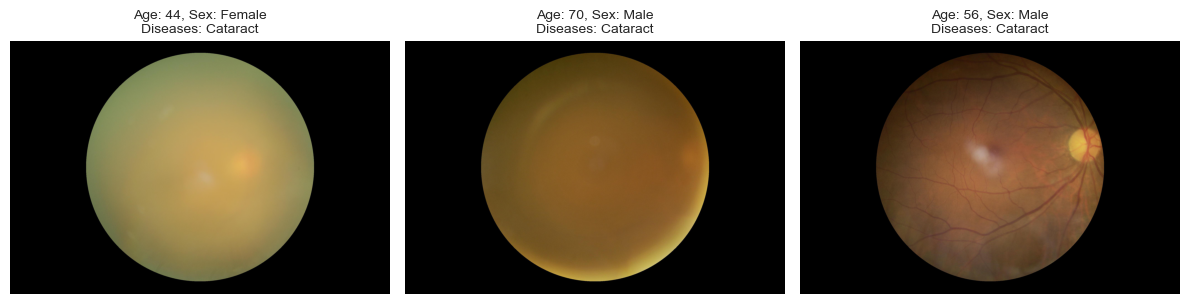


Age-related Macular Degeneration (A):


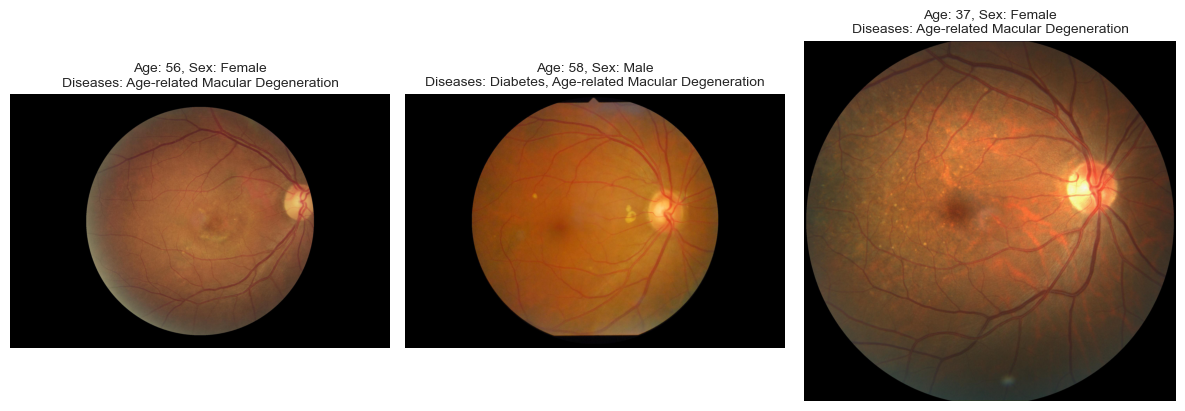


Hypertension (H):


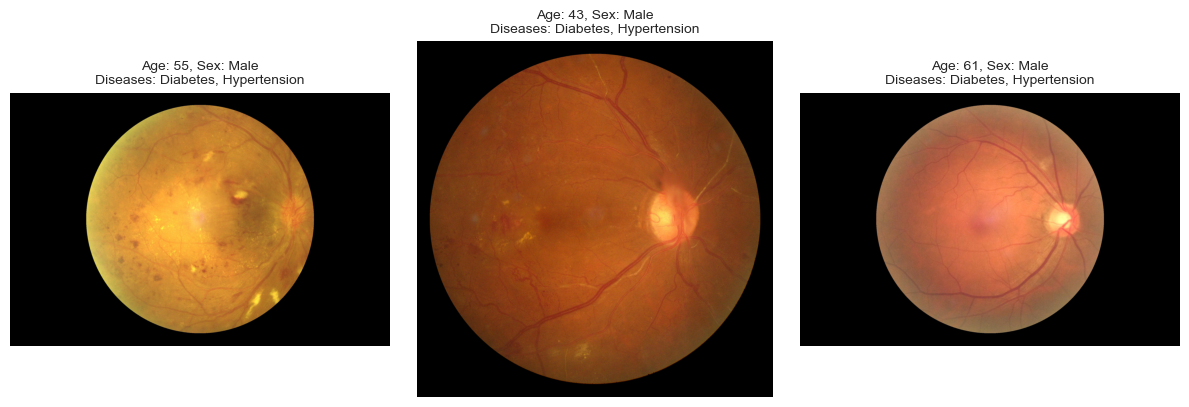


Pathological Myopia (M):


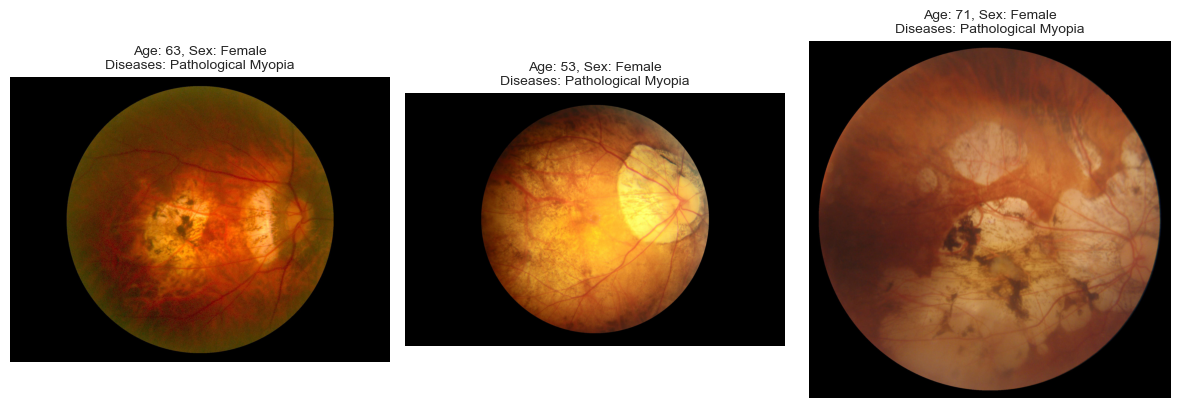


Other diseases/abnormalities (O):


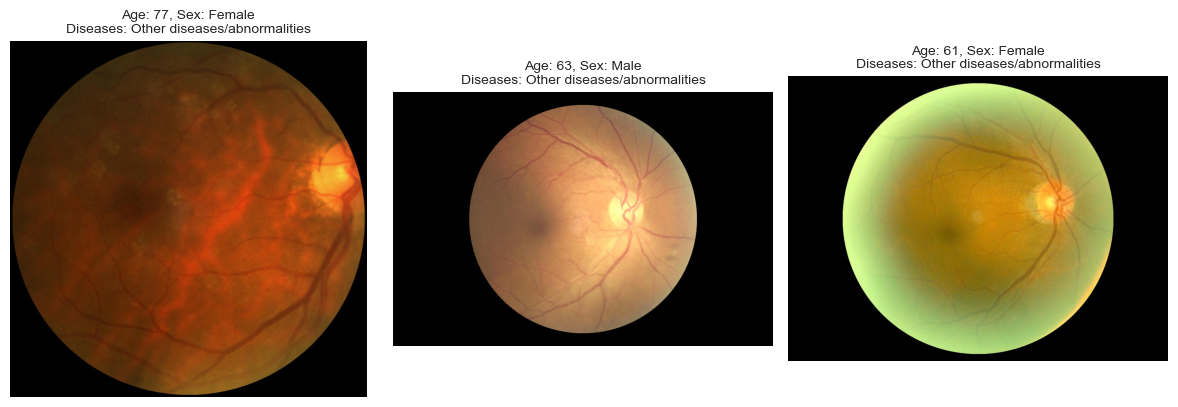

In [ ]:
# Visualize samples for each disease category
print("Visualizing samples by disease category...\n")

for label in LABEL_COLUMNS:
    if label in df.columns:
        disease_df = df[df[label] == 1]
        if len(disease_df) > 0:
            print(f"\n{DISEASE_LABELS[label]} ({label}):")
            visualize_samples(disease_df, n_samples=3, image_column='Right-Fundus', show_labels=True)

## 9. Data Quality Checks

In [ ]:
# Check for missing values
print("Missing values by column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Missing values by column:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [ ]:
# Check for duplicate records
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check ID uniqueness
if 'ID' in df.columns:
    print(f"Unique IDs: {df['ID'].nunique()}")
    print(f"Total rows: {len(df)}")


Duplicate rows: 0
Unique IDs: 3358
Total rows: 6392


## 10. Summary and Insights

In [ ]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nTotal patients: {len(df)}")
print(f"\nDisease distribution:")
for _, row in disease_stats.iterrows():
    print(f"  {row['Disease Code']} ({row['Disease Name']}): {row['Count']} ({row['Percentage']})")

print(f"\nMulti-label statistics:")
print(f"  Single disease: {multilabel_analysis['single_disease']} patients")
print(f"  Multiple diseases: {multilabel_analysis['multiple_diseases']} patients")
print(f"  Average diseases per patient: {multilabel_analysis['avg_diseases_per_patient']:.2f}")

if 'Patient Age' in df.columns:
    print(f"\nAge statistics:")
    print(f"  Mean: {df['Patient Age'].mean():.1f} years")
    print(f"  Median: {df['Patient Age'].median():.1f} years")
    print(f"  Range: {df['Patient Age'].min():.0f} - {df['Patient Age'].max():.0f} years")

if 'Patient Sex' in df.columns:
    print(f"\nGender distribution:")
    for gender, count in df['Patient Sex'].value_counts().items():
        pct = (count / len(df)) * 100
        print(f"  {gender}: {count} ({pct:.1f}%)")

print("\n" + "="*60)

DATASET SUMMARY

Total patients: 6392

Disease distribution:
  N (Normal): 2101 (32.87%)
  D (Diabetes): 2123 (33.21%)
  G (Glaucoma): 397 (6.21%)
  C (Cataract): 402 (6.29%)
  A (Age-related Macular Degeneration): 319 (4.99%)
  H (Hypertension): 203 (3.18%)
  M (Pathological Myopia): 306 (4.79%)
  O (Other diseases/abnormalities): 1588 (24.84%)

Multi-label statistics:
  Single disease: 5391 patients
  Multiple diseases: 1001 patients
  Average diseases per patient: 1.16

Age statistics:
  Mean: 57.9 years
  Median: 59.0 years
  Range: 1 - 91 years

Gender distribution:
  Male: 3424 (53.6%)
  Female: 2968 (46.4%)



## Next Steps

1. **Data Preprocessing**: Resize images, normalize pixel values, augment data
2. **Train/Validation/Test Split**: Split dataset for model training
3. **Model Development**: Build CNN or transfer learning model for multi-label classification
4. **Evaluation**: Use appropriate metrics (AUC-ROC, F1-score, precision, recall)
5. **Interpretability**: Use GradCAM or similar techniques to visualize model predictions